# Porównawcza analiza skuteczności algorytmów uczenia maszynowego w zadaniu klasyfikacji binarnej zadowolenia pasażerów linii lotniczych na podstawie zbioru danych Airline Passenger Satisfaction.

**Dominika Boguszewska, Natalia Pieczko** — Zaawansowane Uczenie Maszynowe, czerwiec 2026

## Cel projektu

Celem projektu jest przeprowadzenie procesu analitycznego mającego na celu budowę i ocenę modeli klasyfikacyjnych przewidujących poziom satysfakcji klientów linii lotniczych. Obejmuje on eksploracyjną analizę danych, ich przygotowanie (w tym kodowanie zmiennych oraz standaryzację) oraz inżynierię cech.

Istotnym elementem pracy jest porównanie różnych metod selekcji cech oraz ich wpływu na jakość modeli. Przeprowadzono trenowanie, strojenie hiperparametrów i porównanie wybranych algorytmów klasyfikacyjnych z wykorzystaniem walidacji krzyżowej i odpowiednich metryk jakości, w celu wyłonienia najlepszego rozwiązania.

## Założenia wstępne

### Zbiór danych

Zbiór danych "Airline Passenger Satisfaction" zawiera informacje o pasażerach linii lotniczych, ich doświadczeniach oraz poziomie satysfakcji. Dane obejmują zarówno cechy demograficzne, jak i związane z podróżą, takie jak oceny usług czy opóźnienia lotów.

Zmienną docelową jest atrybut `satisfaction` przyjmujący dwie wartości: `satisfied` (klasa pozytywna) i `neutral or dissatisfied` (klasa negatywna). Rozkład klas jest względnie zrównoważony (43% pozytywnych, 57% negatywnych), co pozwala na zastosowanie standardowych metryk oceny bez konieczności dodatkowych technik radzenia sobie z niezrównoważonymi danymi. Zbiór jest stosunkowo duży i został podzielony na część treningową (ok. 104 000 próbek) oraz testową (ok. 26 000 próbek).

Dane zawierają 23 cechy opisujące pasażera oraz przebieg lotu, w tym informacje demograficzne (np. wiek, płeć), operacyjne (np. dystans lotu, klasa podróży) oraz oceny jakości poszczególnych usług pokładowych.

### Badane parametry algorytmów

| Algorytm | Parametry |
|---|---|
| Regresja logistyczna | `C`, `l1_ratio` (0.0 = L2, 1.0 = L1) |
| Las losowy | `n_estimators`, `max_depth`, `min_samples_split` |
| XGBoost | `n_estimators`, `max_depth`, `learning_rate` |
| TabPFN | ustawienia domyślne (model nie wymaga strojenia) |
| SelectKBest | `k` (liczba cech), `score_func` (`f_classif`, `mutual_info_classif`) |
| RFE | `n_features_to_select`, `estimator` (LR, RF) |

### Procedura oceny modeli

W Eksperymencie 1 hiperparametry modeli klasycznych (LR, RF, XGBoost) strojono metodą GridSearchCV z 5-krotną stratyfikowaną walidacją krzyżową (kryterium: F1). Najlepszy model każdego algorytmu poddano następnie ponownej 5-krotnej CV na pełnym zbiorze treningowym w celu oszacowania wariancji jakości, a ocenę końcową wyznaczono na wydzielonym zbiorze testowym.
### Metryki oceny

Zgodnie ze wstępnymi założenami projektu, do oceny jakości modeli klasyfikacyjnych wykorzystano następujące metryki:
- Dokładność (accuracy)
- Precyzja (precision)
- Miara F1 (F1-score)
- Krzywa ROC i pole pod krzywą (AUC)
- Krzywa Precision-Recall

### Aktualizacje założeń wstępnych

Poniżej zestawiono założenia dokumentu wstępnego ze zmianami wprowadzonymi w trakcie implementacji.

| Obszar | Założenie wstępne | Decyzja implementacyjna |
|---|---|---|
| Regularyzacja regresji logistycznej | `penalty ∈ {l1, l2}` | `l1_ratio ∈ {0.0, 1.0}` — sklearn 1.8 zdeprecjonował `penalty`; `l1_ratio=0.0` - regularyzacja L2, `l1_ratio=1.0` - regularyzacja L1 |
| Hiperparametry lasu losowego | `n_estimators`, `max_depth` | Dodano `min_samples_split` jako trzeci strojony parametr |
| Braki danych | Do ustalenia po EDA | Usunięcie wierszy (braki tylko w `Arrival Delay in Minutes`, <0,4%) |
| Inżynieria cech | Do ustalenia po EDA | Stworzono `total_delay` i `avg_service_score` |
| Rozmiary próbek (TabPFN) | ~1000 próbek | [100, 250, 500] ze względu na ograniczenia pamięciowe |

## Konfiguracja środowiska (Google Colab)

Poniższe komórki konfigurują środowisko. Uruchom je kolejno przed właściwą analizą. Lokalnie (poza Colabem) zostaną automatycznie pominięte.

**Wymagane sekrety Colab** (ikona 🔑 w lewym panelu → *Add new secret*):
| Nazwa | Wartość |
|---|---|
| `KAGGLE_USERNAME` | Twoja nazwa użytkownika Kaggle |
| `KAGGLE_KEY` | Klucz API z [kaggle.com/settings](https://www.kaggle.com/settings) → *API* → *Create New Token* |

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_path = "/content/Airline_Passenger_Satisfaction_Classification"
    if not os.path.exists(repo_path):
        os.system(
            "git clone https://github.com/nataliap203/Airline_Passenger_Satisfaction_Classification.git "
            + repo_path
        )
    os.chdir(repo_path + "/notebooks")
    print("Katalog roboczy:", os.getcwd())

Katalog roboczy: /content/Airline_Passenger_Satisfaction_Classification/notebooks


In [2]:
if IN_COLAB:
    import subprocess, sys
    # numpy, scikit-learn, pandas, matplotlib, xgboost są pre-instalowane w Colab
    # instalujemy tylko pakiety których Colab nie zawiera
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "tabpfn>=8.0.3",
        "kaggle",
    ])
    print("Zależności gotowe.")

Zależności gotowe.


In [3]:
if IN_COLAB:
    import json
    from pathlib import Path
    from google.colab import userdata

    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(exist_ok=True)
    kaggle_path = kaggle_dir / "kaggle.json"

    if not kaggle_path.exists():
        with open(kaggle_path, "w") as f:
            json.dump({
                "username": userdata.get("KAGGLE_USERNAME"),
                "key": userdata.get("KAGGLE_KEY"),
            }, f)
        kaggle_path.chmod(0o600)
        print("Dane uwierzytelniające Kaggle skonfigurowane.")
    else:
        print("kaggle.json już istnieje.")

Dane uwierzytelniające Kaggle skonfigurowane.


## 1. Pobranie danych i import bibliotek

In [4]:
import importlib
import sys

_sklearn_ensemble = importlib.import_module("sklearn.ensemble._forest")
SklearnRF = _sklearn_ensemble.RandomForestClassifier

In [5]:
%load_ext cuml.accel

In [6]:
import kaggle
from pathlib import Path

DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

kaggle.api.authenticate()
kaggle.api.dataset_download_files(
    "teejmahal20/airline-passenger-satisfaction",
    path=DATA_DIR,
    unzip=True,
)

print("Pobrane pliki:")
for f in sorted(DATA_DIR.iterdir()):
    print(f"  {f.name}")

Dataset URL: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
Pobrane pliki:
  test.csv
  train.csv


In [7]:
import os
import sys
import pandas as pd
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning:pkg_resources"

sys.path.append("..")

from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression

from src.preprocessing import (
    load_data,
    analyze_missing_values,
    clean_data,
    build_preprocessor,
    plot_correlation_matrix,
    plot_target_correlation,
    engineer_features,
    split_X_y,
)
from src.evaluation import evaluate, cross_validate_model, plot_pr_curve, plot_roc_curve, plot_model_metric_comparison, plot_pr_curves, plot_roc_curves
from src.models.xgboost_model import tune_hyperparameters
from src.models.logistic_regression import tune_hyperparameters as tune_hyperparameters_lr
from src.models.random_forest import tune_hyperparameters as tune_hyperparameters_rf
from src.scripts.run_selectkbest_experiment import (
    run_selectkbest_experiment,
    get_feature_scores,
    plot_k_vs_metrics,
    plot_feature_scores,
    plot_rank_comparison,
)
from src.scripts.run_rfe_experiment import (
    run_rfe_experiment,
    get_feature_rankings,
    plot_n_features_vs_metrics,
    plot_feature_rankings,
    plot_feature_rankings_comparison,
    _RFE_ESTIMATORS,
)

## 2. Przygotowanie danych

### 2.1 Ładowanie danych i analiza brakujących wartości

In [8]:
train, test = load_data()

print("=== Train ===")
print(train.shape)
train.head()

=== Train ===
(103904, 24)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [9]:
print("=== Braki w train ===")
analyze_missing_values(train)

print("\n=== Braki w test ===")
analyze_missing_values(test)

=== Braki w train ===
                          count  percent
Arrival Delay in Minutes    310      0.3

=== Braki w test ===
                          count  percent
Arrival Delay in Minutes     83     0.32


### 2.2 Czyszczenie danych

Braki wykryto wyłącznie w `Arrival Delay in Minutes` (~0,3% obserwacji). Zastosowano usunięcie wierszy z brakującymi wartościami.

In [10]:
train_clean = clean_data(train)
test_clean = clean_data(test)

print("Train po czyszczeniu:", train_clean.shape)
print("Test po czyszczeniu: ", test_clean.shape)

Train po czyszczeniu: (103594, 23)
Test po czyszczeniu:  (25893, 23)


### 2.3 Analiza korelacji

Macierz korelacji identyfikuje zależności między cechami numerycznymi. Analiza korelacji z zmienną docelową wskazuje najsilniejsze predykatory satysfakcji — wyniki stanowią podstawę inżynierii cech.

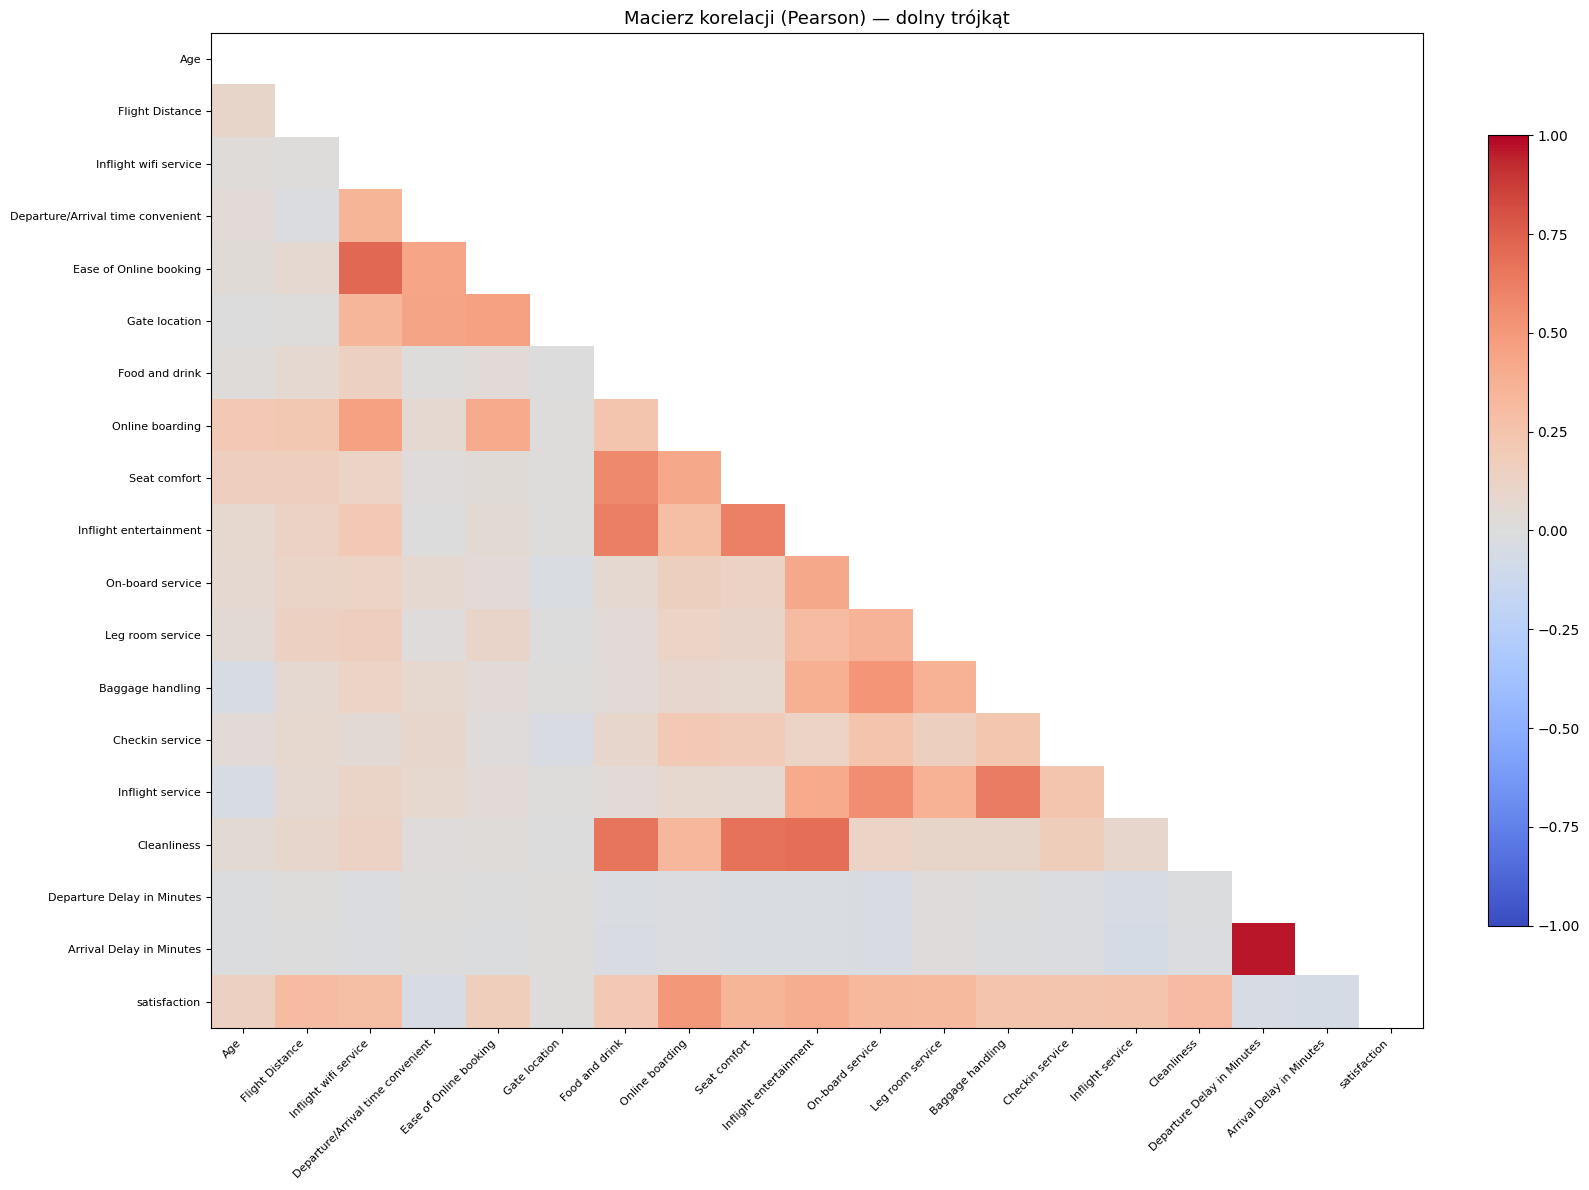

In [11]:
plot_correlation_matrix(train_clean)

Macierz korelacji wskazuje, że większość ocen jakości usług pokładowych i lotniskowych jest dodatnio skorelowana ze sobą. Najsilniejsze zależności występują między ocenami dotyczącymi komfortu podróży, takimi jak `Seat comfort`, `Inflight entertainment`, `Food and drink`, `Cleanliness` oraz obsługi, takimi jak `Inflight service`, `Baggage handling` i `On-board service`, co sugeruje, że pasażerowie wysoko oceniający jeden aspekt podróży zwykle wysoko oceniają również pozostałe.

Dla zmiennej docelowej `satisfaction` widoczne są głównie umiarkowane dodatnie korelacje z cechami związanymi z jakością usług. Najsilniej z satysfakcją powiązane są:
- `Online boarding`,
- `Inflight entertainment`,
- `Seat comfort`,
- `On-board service`,
- `Leg room service`,
- `Cleanliness`,
- `Fligth distance`.

Z kolei `Departure Delay in Minutes` i `Arrival Delay in Minutes` wykazują silną dodatnią korelację między sobą, co jest naturalne – opóźniony odlot często skutkuje opóźnionym przylotem. Jednocześnie ich korelacja z `satisfaction` jest słaba i ujemna, co sugeruje, że większe opóźnienia nieznacznie obniżają poziom satysfakcji pasażerów.

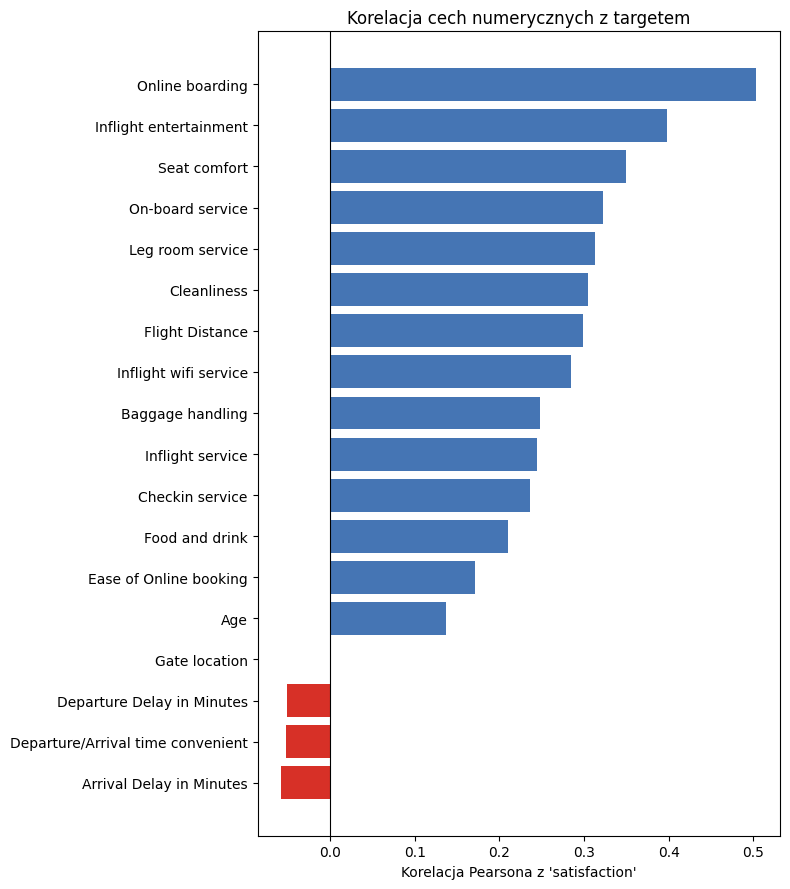

In [12]:
plot_target_correlation(train_clean)

Najsilniejszą dodatnią korelację z `satisfaction` wykazuje `Online boarding` (ok. 0.50), co sugeruje, że sprawny proces wejścia na pokład ma największy związek z zadowoleniem pasażerów. Wysokie dodatnie korelacje obserwowane są również dla `Inflight entertainment`, `Seat comfort`, `On-board service`, `Leg room service`, `Cleanliness`, `Flight Distance` oraz `Inflight wifi service`, co wskazuje, że jakość usług podczas lotu istotnie wpływa na poziom satysfakcji.

Z kolei `Departure Delay in Minutes` oraz `Arrival Delay in Minutes` są ujemnie skorelowane z `satisfaction`, co oznacza, że większe opóźnienia wiążą się z niższym poziomem zadowolenia pasażerów.

Najsłabszą zależność z targetem wykazuje `Gate location`, której korelacja jest bliska zeru, co sugeruje niewielki wpływ tej cechy na satysfakcję klientów.

### 2.4 Inżynieria cech

Na podstawie analizy danych stworzono dwie nowe cechy agregujące:
- **`total_delay`** — suma opóźnienia przylotu i wylotu (łączne doświadczenie opóźnienia)
- **`avg_service_score`** — średnia ocen 13 usług pokładowych (okazuje się najsilniejszym predyktorem)

In [13]:
train_feat = engineer_features(train_clean)
test_feat = engineer_features(test_clean)

print("Nowe kolumny:", [c for c in train_feat.columns if c not in train_clean.columns])
train_feat[["Departure Delay in Minutes", "Arrival Delay in Minutes", "total_delay", "avg_service_score"]].describe()

Nowe kolumny: ['total_delay', 'avg_service_score']


,Departure Delay in Minutes,Arrival Delay in Minutes,total_delay,avg_service_score
count,103594.000000,103594.000000,103594.000000,103594.000000
mean,14.747939,15.178678,29.926617,3.261133
std,38.116737,38.698682,76.149672,0.687609
min,0.000000,0.000000,0.000000,0.846154
25%,0.000000,0.000000,0.000000,2.769231
50%,0.000000,0.000000,2.000000,3.307692
75%,12.000000,13.000000,24.000000,3.769231
max,1592.000000,1584.000000,3176.000000,5.000000


### 2.5 Podział danych i preprocessing

Dane podzielono zgodnie z oryginalnym podziałem Kaggle: ~104 000 próbek treningowych, ~26 000 testowych. Pipeline preprocessingu (fitowany wyłącznie na zbiorze treningowym) obejmuje standaryzację cech numerycznych i one-hot encoding zmiennych kategorycznych. Łącznie uzyskano 29 cech po kodowaniu.

In [14]:
X_train, y_train = split_X_y(train_feat)
X_test, y_test = split_X_y(test_feat)

preprocessor = build_preprocessor(X_train)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Rozkład klas y_train:\n", y_train.value_counts())

X_train shape: (103594, 24)
X_test shape:  (25893, 24)
Rozkład klas y_train:
 satisfaction
0    58697
1    44897
Name: count, dtype: int64


## 3. Eksperyment 1 — Porównanie modeli klasycznych i zespołowych

**Pytanie badawcze:** Jak duży przyrost jakości predykcji oferują modele zespołowe w porównaniu do regresji logistycznej?

**Hipoteza:** XGBoost, dzięki technice gradient boosting, osiągnie najwyższe wyniki na pełnym zbiorze danych.

Każdy model poddano strojeniu hiperparametrów metodą GridSearchCV (5-krotna CV, kryterium: F1). Ocena końcowa na wydzielonym zbiorze testowym, uzupełniona krzywą Precision-Recall i krzywą ROC, pozwoliła na kompleksowe porównanie modeli.

### 3.1 Regresja logistyczna (baseline)

In [15]:
search = tune_hyperparameters_lr(preprocessor, X_train, y_train)

print("Najlepsze parametry:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepsze F1 (CV): {search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Najlepsze parametry:
  model__C: 1.0
  model__l1_ratio: 0.0

Najlepsze F1 (CV): 0.8528


In [16]:
cv_scores = cross_validate_model(search.best_estimator_, X_train, y_train)

print("Walidacja krzyżowa najlepszego modelu (5-fold):")
print(cv_scores.to_string(index=False))
print("\nŚrednie:")
print(cv_scores.mean().map("{:.4f}".format).to_string())
print("\nOdchylenia standardowe:")
print(cv_scores.std().map("{:.4f}".format).to_string())

Walidacja krzyżowa najlepszego modelu (5-fold):
 accuracy       f1  roc_auc
 0.875477 0.853359 0.924828
 0.870554 0.847475 0.925352
 0.878131 0.856412 0.927552
 0.876345 0.855320 0.929050
 0.875036 0.852352 0.926804

Średnie:
accuracy    0.8751
f1          0.8530
roc_auc     0.9267

Odchylenia standardowe:
accuracy    0.0028
f1          0.0035
roc_auc     0.0017


In [17]:
best_model_lr = search.best_estimator_
metrics_lr = evaluate(best_model_lr, X_test, y_test)

accuracy    0.8717
f1          0.8507
roc_auc     0.9255

              precision    recall  f1-score   support

dissatisfied       0.87      0.90      0.89     14528
   satisfied       0.87      0.83      0.85     11365

    accuracy                           0.87     25893
   macro avg       0.87      0.87      0.87     25893
weighted avg       0.87      0.87      0.87     25893



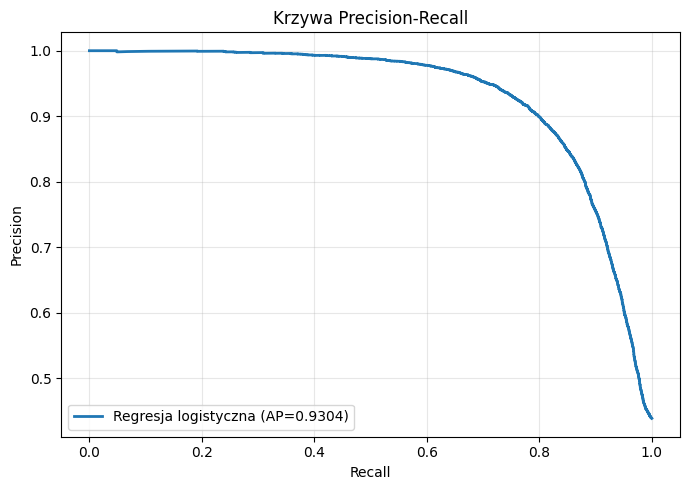

In [18]:
plot_pr_curve(best_model_lr, X_test, y_test, label="Regresja logistyczna")

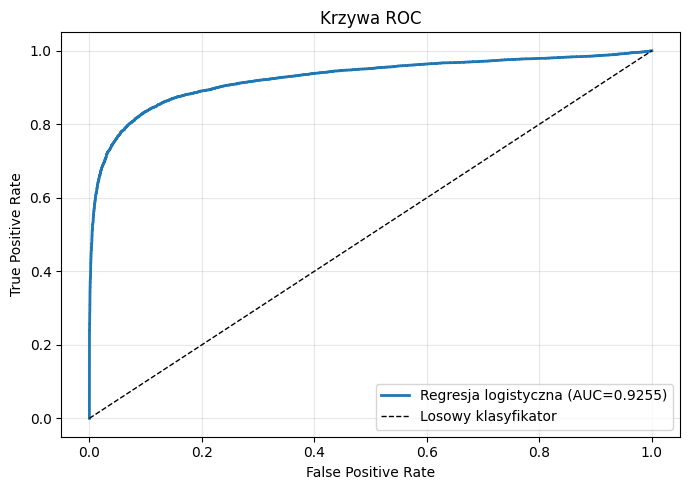

In [19]:
plot_roc_curve(best_model_lr, X_test, y_test, label="Regresja logistyczna")

### 3.2 Las losowy

In [20]:
search = tune_hyperparameters_rf(preprocessor, X_train, y_train)

print("Najlepsze parametry:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepsze F1 (CV): {search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Najlepsze parametry:
  model__max_depth: 20
  model__min_samples_split: 5
  model__n_estimators: 300

Najlepsze F1 (CV): 0.9559


In [21]:
cv_scores = cross_validate_model(search.best_estimator_, X_train, y_train)

print("Walidacja krzyżowa najlepszego modelu (5-fold):")
print(cv_scores.to_string(index=False))
print("\nŚrednie:")
print(cv_scores.mean().map("{:.4f}".format).to_string())
print("\nOdchylenia standardowe:")
print(cv_scores.std().map("{:.4f}".format).to_string())

Walidacja krzyżowa najlepszego modelu (5-fold):
 accuracy       f1  roc_auc
 0.961871 0.955377 0.994425
 0.960761 0.954018 0.993576
 0.962016 0.955428 0.993729
 0.962884 0.956639 0.993887
 0.963413 0.957194 0.993941

Średnie:
accuracy    0.9622
f1          0.9557
roc_auc     0.9939

Odchylenia standardowe:
accuracy    0.0010
f1          0.0012
roc_auc     0.0003


In [22]:
best_model_rf = search.best_estimator_
metrics_rf = evaluate(best_model_rf, X_test, y_test)

accuracy    0.9625
f1          0.9567
roc_auc     0.9940

              precision    recall  f1-score   support

dissatisfied       0.96      0.98      0.97     14528
   satisfied       0.97      0.94      0.96     11365

    accuracy                           0.96     25893
   macro avg       0.96      0.96      0.96     25893
weighted avg       0.96      0.96      0.96     25893



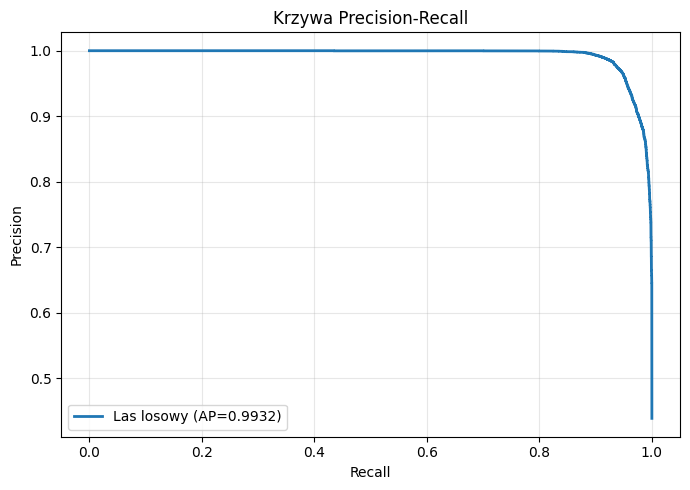

In [23]:
plot_pr_curve(best_model_rf, X_test, y_test, label="Las losowy")

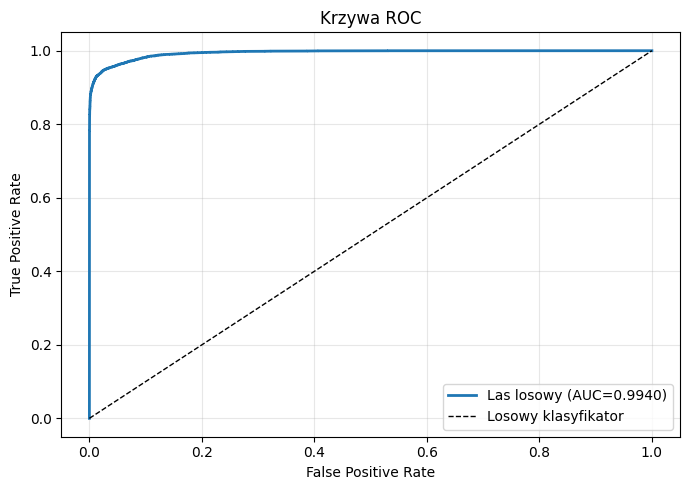

In [24]:
plot_roc_curve(best_model_rf, X_test, y_test, label="Las losowy")

### 3.3 XGBoost

In [25]:
search = tune_hyperparameters(preprocessor, X_train, y_train)

print("Najlepsze parametry:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepsze F1 (CV): {search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Najlepsze parametry:
  model__learning_rate: 0.1
  model__max_depth: 7
  model__n_estimators: 300

Najlepsze F1 (CV): 0.9573


In [26]:
cv_scores = cross_validate_model(search.best_estimator_, X_train, y_train)

print("Walidacja krzyżowa najlepszego modelu (5-fold):")
print(cv_scores.to_string(index=False))
print("\nŚrednie:")
print(cv_scores.mean().map("{:.4f}".format).to_string())
print("\nOdchylenia standardowe:")
print(cv_scores.std().map("{:.4f}".format).to_string())

Walidacja krzyżowa najlepszego modelu (5-fold):
 accuracy       f1  roc_auc
 0.963801 0.957684 0.995585
 0.962884 0.956532 0.994962
 0.962064 0.955478 0.995068
 0.963319 0.957144 0.995379
 0.965585 0.959674 0.995244

Średnie:
accuracy    0.9635
f1          0.9573
roc_auc     0.9952

Odchylenia standardowe:
accuracy    0.0013
f1          0.0016
roc_auc     0.0002


In [27]:
best_model_xgb = search.best_estimator_
metrics_xgb = evaluate(best_model_xgb, X_test, y_test)

accuracy    0.9640
f1          0.9585
roc_auc     0.9954

              precision    recall  f1-score   support

dissatisfied       0.96      0.98      0.97     14528
   satisfied       0.97      0.95      0.96     11365

    accuracy                           0.96     25893
   macro avg       0.97      0.96      0.96     25893
weighted avg       0.96      0.96      0.96     25893



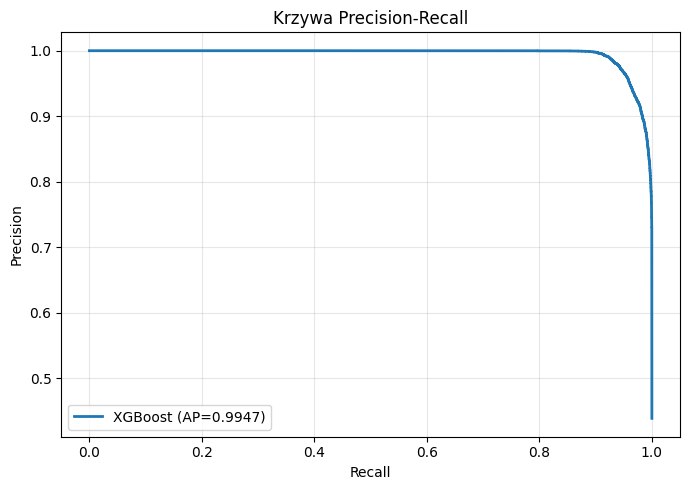

In [28]:
plot_pr_curve(best_model_xgb, X_test, y_test, label="XGBoost")

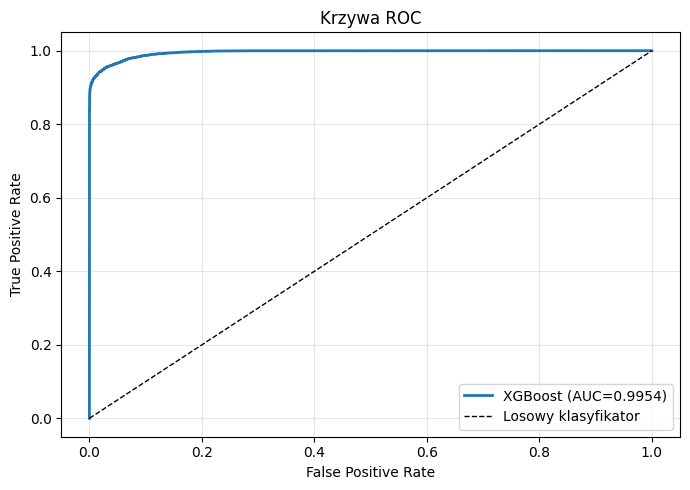

In [29]:
plot_roc_curve(best_model_xgb, X_test, y_test, label="XGBoost")

### 3.4 Porównanie modeli

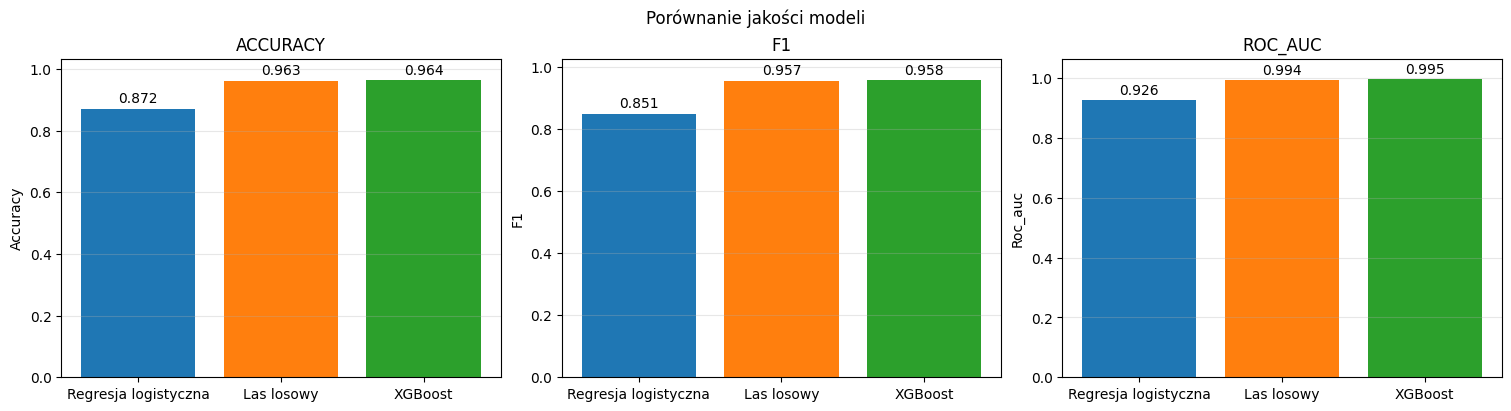

In [30]:
metrics_dict = {
    "Regresja logistyczna": metrics_lr,
    "Las losowy": metrics_rf,
    "XGBoost": metrics_xgb,
}

plot_model_metric_comparison(metrics_dict)

- Regresja Logistyczna odstaje od pozostałych modeli, osiągając najniższe wyniki we wszystkich trzech metrykach.
- Modele oparte na drzewach decyzyjnych (Random Forest i XGBoost) radzą sobie znacznie lepiej i osiągają bardzo wysokie, zbliżone do siebie rezultaty (ponad 0.95 dla Accuracy i F1 oraz niemal 1.0 dla ROC AUC).
- XGBoost okazuje się najlepszym modelem we wszystkich trzech kategoriach, choć jego przewaga nad modelem Random Forest jest marginalna.

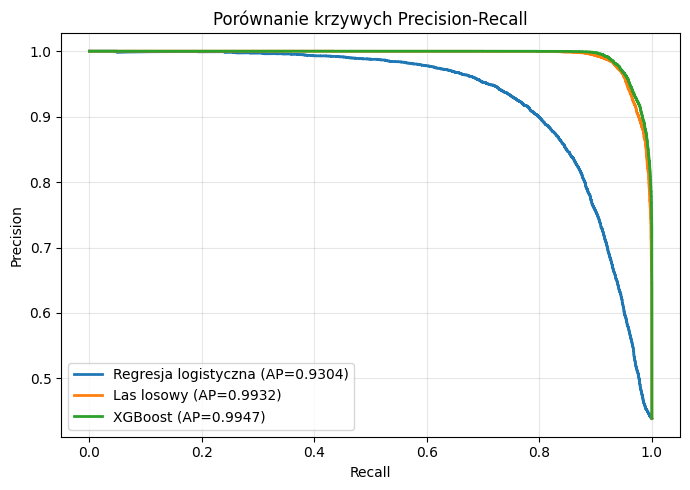

In [31]:
models = [best_model_lr, best_model_rf, best_model_xgb]
labels = ["Regresja logistyczna", "Las losowy", "XGBoost"]

plot_pr_curves(models, X_test, y_test, labels)

- Zarówno XGBoost, jak i Random Forest radzą sobie doskonale. Utrzymują niemal idealną precyzję (blisko 1.0) aż do momentu, gdy czułość przekracza poziom 0.9.
- XGBoost jest nieznacznie lepszy, co widać po tym, że jego krzywa znajduje się minimalnie wyżej w fazie spadku. Potwierdza to również najwyższa wartość pola pod krzywą.
- Model regresji logistycznej wyraźnie odstaje od pozostałych. Jego precyzja zaczyna stopniowo i zauważalnie spadać już przy czułości na poziomie około 0.6, co przekłada się na najniższy ogólny wynik AP.

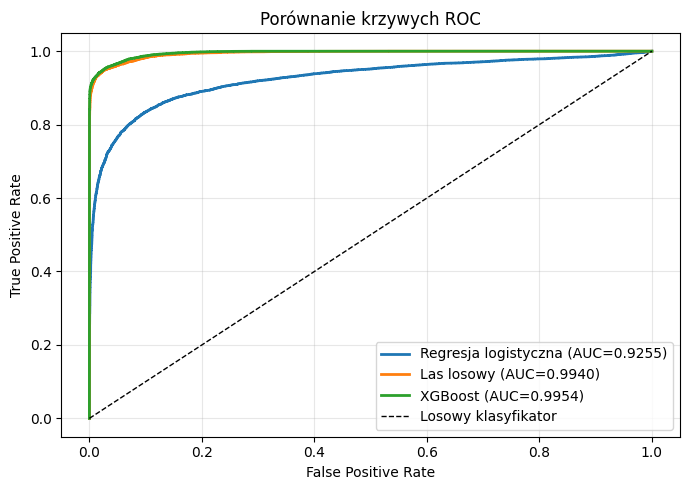

In [32]:
plot_roc_curves(models, X_test, y_test, labels)

- Zarówno XGBoost, jak i Random Forest osiągają wyniki bliskie ideałowi (1.0). Ich krzywe błyskawicznie pną się w stronę lewego górnego rogu, co oznacza, że modele te potrafią bezbłędnie zidentyfikować większość pozytywnych przypadków (True Positive Rate) przy niemal zerowym udziale błędnych alarmów (False Positive Rate).
- Wskaźnik AUC dla krzywej ROC ostatecznie pieczętuje pozycję XGBoost jako najlepszego modelu w tym zestawieniu, zachowując minimalną przewagę nad Lasem Losowym.
- Mimo że Regresja Logistyczna wyraźnie ustępuje rywalom, jej wynik (AUC = 0.9255) wciąż jest bardzo wysoki. Pokazuje to, że w danych tkwi silny i wyraźny sygnał predykcyjny, dzięki czemu nawet prostszy model liniowy radzi sobie wielokrotnie lepiej niż klasyfikator losowy.

### 3.5 Wnioski z Eksperymentu 1

In [33]:
results_exp1 = (
    pd.DataFrame(
        {"Regresja logistyczna": metrics_lr, "Las losowy": metrics_rf, "XGBoost": metrics_xgb}
    )
    .T.rename(columns={"accuracy": "Accuracy", "f1": "F1", "roc_auc": "ROC AUC"})
)
results_exp1.index.name = "Model"
results_exp1.round(4).style.highlight_max(axis=0, props="font-weight: bold; color: green")

,Accuracy,F1,ROC AUC
Model,,,
Regresja logistyczna,0.871700,0.850700,0.925500
Las losowy,0.962500,0.956700,0.994000
XGBoost,0.964000,0.958500,0.995400


Zgodnie z postawioną hipotezą, modele zespołowe (Las Losowy oraz XGBoost) wyraźnie przewyższają Regresję Logistyczną pod względem jakości predykcji. Różnica ta jest szczególnie widoczna w przypadku metryki F1, gdzie modele zespołowe wykazują poprawę o ~10 punktów procentowych.

XGBoost oraz Las Losowy osiągają bardzo zbliżone, znakomite wyniki (F1 ~0.96, ROC AUC na poziomie ~0.995). Ich przewagę doskonale obrazuje również krzywa Precision-Recall, gdzie przebieg dla obu modeli zespołowych jest niemal identyczny i utrzymuje się bardzo blisko wartości maksymalnych (Average Precision na poziomie ~0.99). Wskazuje to na wysoką zdolność obu tych podejść do skutecznego uchwycenia złożonych, nieliniowych zależności w analizowanym zbiorze danych. XGBoost okazał się nieznacznie, marginalnie lepszy we wszystkich metrykach.

Regresja logistyczna, mimo zauważalnie niższych wyników na każdym z wykresów, nadal stanowi solidny i użyteczny punkt odniesienia (tzw. baseline). Jej dodatkową zaletą w tym kontekście jest przejrzystość – dostarcza ona wysoce interpretowalnych wag poszczególnych cech, czego brakuje "czarnym skrzynkom", jakimi bywają zaawansowane modele zespołowe.

## 4. Eksperyment 2 — Efektywność próbkowania z wykorzystaniem TabPFN

**Pytanie badawcze:** Czy pretrenowany model oparty na architekturze Transformer (TabPFN) potrafi osiągnąć lepsze wyniki generalizacji na bardzo małym zbiorze treningowym w porównaniu do klasycznych metod uczenia maszynowego?

**Hipoteza:** Przy mocno ograniczonej liczbie próbek treningowych TabPFN osiągnie wyższą skuteczność niż XGBoost i Las Losowy trenowane na tych samych danych.

Eksperyment porównuje trzy modele trenowane na losowych podzbiorach treningowych o rozmiarach [100, 250, 500] i ewaluowane na pełnym zbiorze testowym. Modele klasyczne używają najlepszych hiperparametrów znalezionych w Eksperymencie 1. W odróżnieniu od Eksperymentu 1, walidacja krzyżowa nie jest stosowana — celem jest ocena jakości przy dokładnie N próbkach treningowych, a nie szacowanie wariancji modelu.

In [34]:
import subprocess, sys, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

In [35]:
script = "src/scripts/run_tabpfn_experiment.py"
with subprocess.Popen(
    [sys.executable, "-u", str(script)],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    cwd="..",
) as proc:
    for line in iter(proc.stdout.readline, ""):
        print(line, end="", flush=True)
    proc.wait()
    if proc.returncode != 0:
        print(f"\nBłąd: skrypt zakończył się kodem {proc.returncode}")

Ładowanie i przygotowanie danych...
X_train: (103594, 24) → 29 cech po OHE
X_test:  (25893, 24)

--- sample_size = 100 ---
  TabPFN:  f1=0.8803  roc_auc=0.9586
  XGBoost: f1=0.8323  roc_auc=0.9201
/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)
  RF:      f1=0.8516  roc_auc=0.9463
--- sample_size = 250 ---
  TabPFN:  f1=0.9138  roc_auc=0.9817
  XGBoost: f1=0.8898  roc_auc=0.9642
  RF:      f1=0.8732  roc_auc=0.9614
--- sample_size = 500 ---
  TabPFN:  f1=0.9207  roc_auc=0.9841
  XGBoost: f1=0.9094  roc_auc=0.9737
  RF:      f1=0.9034  roc_auc=0.9705

Wyniki zapisane do data/tabpfn_experiment_results.csv


In [36]:
results_df = pd.read_csv("../data/tabpfn_experiment_results.csv").set_index(["model", "sample_size"])
print(results_df.round(4).to_string())

                     accuracy      f1  roc_auc
model   sample_size                           
TabPFN  100            0.8926  0.8803   0.9586
XGBoost 100            0.8519  0.8323   0.9201
RF      100            0.8710  0.8516   0.9463
TabPFN  250            0.9257  0.9138   0.9817
XGBoost 250            0.9021  0.8898   0.9642
RF      250            0.8922  0.8732   0.9614
TabPFN  500            0.9323  0.9207   0.9841
XGBoost 500            0.9214  0.9094   0.9737
RF      500            0.9173  0.9034   0.9705


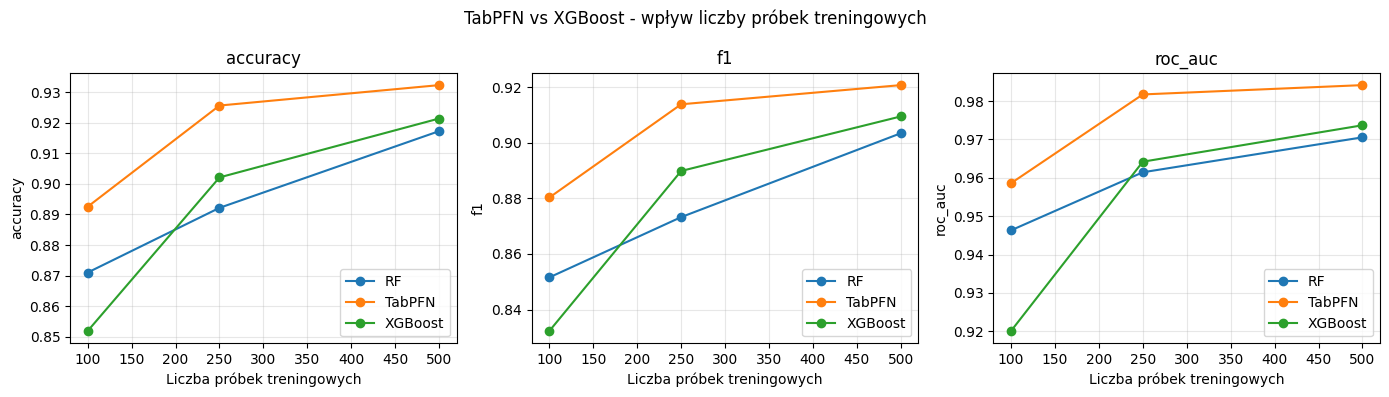

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ["accuracy", "f1", "roc_auc"]):
    for model_name, group in results_df.reset_index().groupby("model"):
        ax.plot(group["sample_size"], group[metric], marker="o", label=model_name)
    ax.set_title(metric)
    ax.set_xlabel("Liczba próbek treningowych")
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("TabPFN vs XGBoost - wpływ liczby próbek treningowych")
plt.tight_layout()
plt.show()

### 4.1 Wnioski z Eksperymentu 2

Zgodnie z postawioną hipotezą, model TabPFN systematycznie przewyższa algorytmy XGBoost i Las Losowy (RF) we wszystkich badanych metrykach (Accuracy, F1, ROC AUC) i przy każdym testowanym rozmiarze zbioru. Wyniki te jednoznacznie demonstrują wyższą efektywność próbkowania.

Analiza krzywych uczenia ukazuje, że różnica w skuteczności między TabPFN a modelami klasycznymi maleje w miarę zwiększania rozmiaru próbki treningowej (od 100 do 500). Modele zespołowe, w szczególności XGBoost, notują bardzo szybki przyrost jakości, co wskazuje, że początkowa ogromna korzyść płynąca z pretrainingu zmniejsza się, gdy tradycyjne algorytmy otrzymują więcej danych do samodzielnego znalezienia wzorców.

Eksperyment potwierdza ogromną przydatność modeli opartych na architekturze Transformer (takich jak TabPFN) w sytuacjach skrajnego niedoboru danych. Potrafią one zapewnić wysoką jakość generalizacji już przy 100 próbkach treningowych, podczas gdy klasyczne modele zespołowe przy tak małym wolumenie danych radzą sobie zauważalnie gorzej.

## 5. Eksperyment 3 — Analiza ważności cech i selekcja

**Pytanie badawcze:** Które z cech lotu i pasażera są najsilniejszymi predykatorami zadowolenia i w jakim stopniu różne metody selekcji cech (SelectKBest, RFE) są ze sobą zgodne w ich identyfikacji?

**Hipoteza:** Oceny usług pokładowych będą dominującymi predyktorami. Rankingi cech uzyskane różnymi metodami będą spójne, a ich selekcja pozwoli uprościć model regresji logistycznej bez pogorszenia jego skuteczności.

### 5.1 SelectKBest

Metoda filtracyjna; wybiera `k` najlepszych cech na podstawie testu statystycznego. Porównano dwie funkcje oceny: `f_classif` (test ANOVA, zależności liniowe) i `mutual_info_classif` (wzajemna informacja, zależności nieliniowe).

In [38]:
results = run_selectkbest_experiment(
    preprocessor, X_train, y_train, X_test, y_test,
    k_values=[5, 10, 15, 20, 25, "all"],
    score_funcs=[f_classif, mutual_info_classif]
)


── f_classif ──
  k=   5  accuracy=0.8448  f1=0.8207  roc_auc=0.9053
  k=  10  accuracy=0.8500  f1=0.8262  roc_auc=0.9090
  k=  15  accuracy=0.8517  f1=0.8283  roc_auc=0.9113
  k=  20  accuracy=0.8702  f1=0.8491  roc_auc=0.9238
  k=  25  accuracy=0.8718  f1=0.8509  roc_auc=0.9255
  k= all  accuracy=0.8713  f1=0.8502  roc_auc=0.9255

── mutual_info_classif ──
  k=   5  accuracy=0.8444  f1=0.8203  roc_auc=0.9051
  k=  10  accuracy=0.8465  f1=0.8228  roc_auc=0.9082
  k=  15  accuracy=0.8552  f1=0.8326  roc_auc=0.9127
  k=  20  accuracy=0.8706  f1=0.8495  roc_auc=0.9241
  k=  25  accuracy=0.8719  f1=0.8510  roc_auc=0.9250
  k= all  accuracy=0.8713  f1=0.8502  roc_auc=0.9255


In [39]:
print(results.to_string(index=False))

         score_func   k  accuracy       f1  roc_auc
          f_classif   5  0.844784 0.820652 0.905279
          f_classif  10  0.849998 0.826157 0.909042
          f_classif  15  0.851697 0.828326 0.911320
          f_classif  20  0.870197 0.849140 0.923804
          f_classif  25  0.871819 0.850878 0.925483
          f_classif all  0.871278 0.850209 0.925451
mutual_info_classif   5  0.844398 0.820318 0.905090
mutual_info_classif  10  0.846484 0.822774 0.908170
mutual_info_classif  15  0.855212 0.832612 0.912721
mutual_info_classif  20  0.870621 0.849506 0.924113
mutual_info_classif  25  0.871896 0.850995 0.925024
mutual_info_classif all  0.871278 0.850209 0.925451


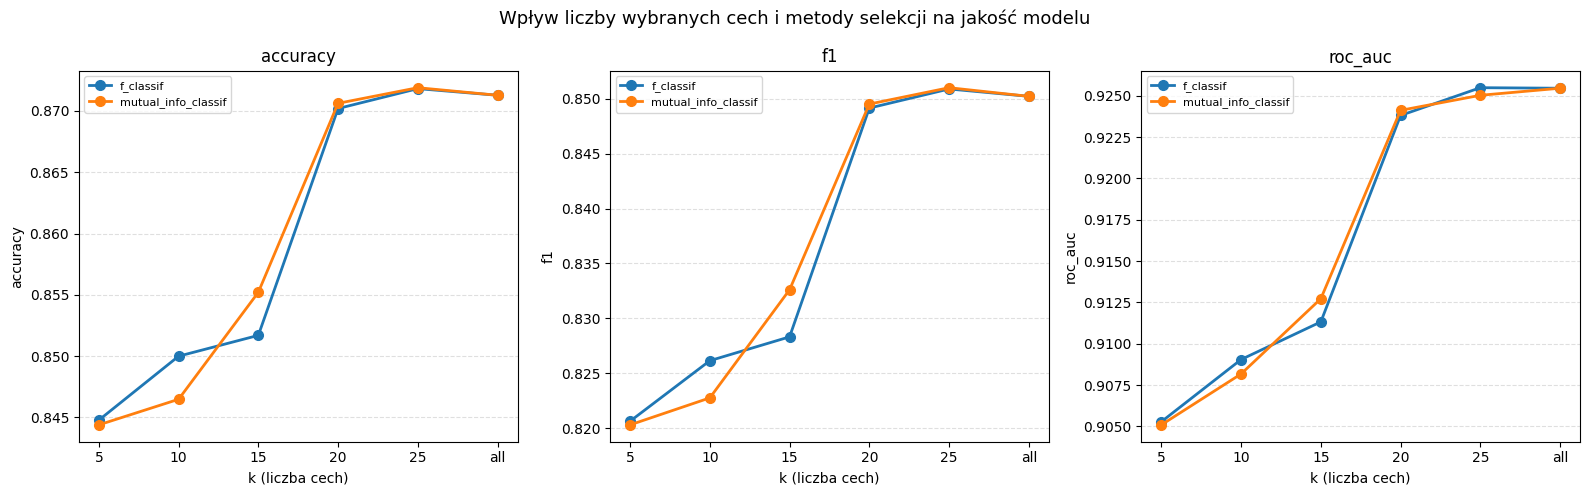

In [40]:
plot_k_vs_metrics(results)

In [41]:
scores_f = get_feature_scores(preprocessor, X_train, y_train, f_classif)
scores_f

,feature,score_func,score,p_value,rank
0,num__avg_service_score,f_classif,37191.832450,0.000000e+00,1
1,cat__Class_Business,f_classif,35263.686115,0.000000e+00,2
2,num__Online boarding,f_classif,35170.633424,0.000000e+00,3
3,cat__Class_Eco,f_classif,26477.193754,0.000000e+00,4
4,cat__Type of Travel_Business travel,f_classif,26156.918063,0.000000e+00,5
5,cat__Type of Travel_Personal Travel,f_classif,26156.918063,0.000000e+00,6
6,num__Inflight entertainment,f_classif,19521.615473,0.000000e+00,7
7,num__Seat comfort,f_classif,14378.120330,0.000000e+00,8
8,num__On-board service,f_classif,12020.742510,0.000000e+00,9
9,num__Leg room service,f_classif,11265.609897,0.000000e+00,10


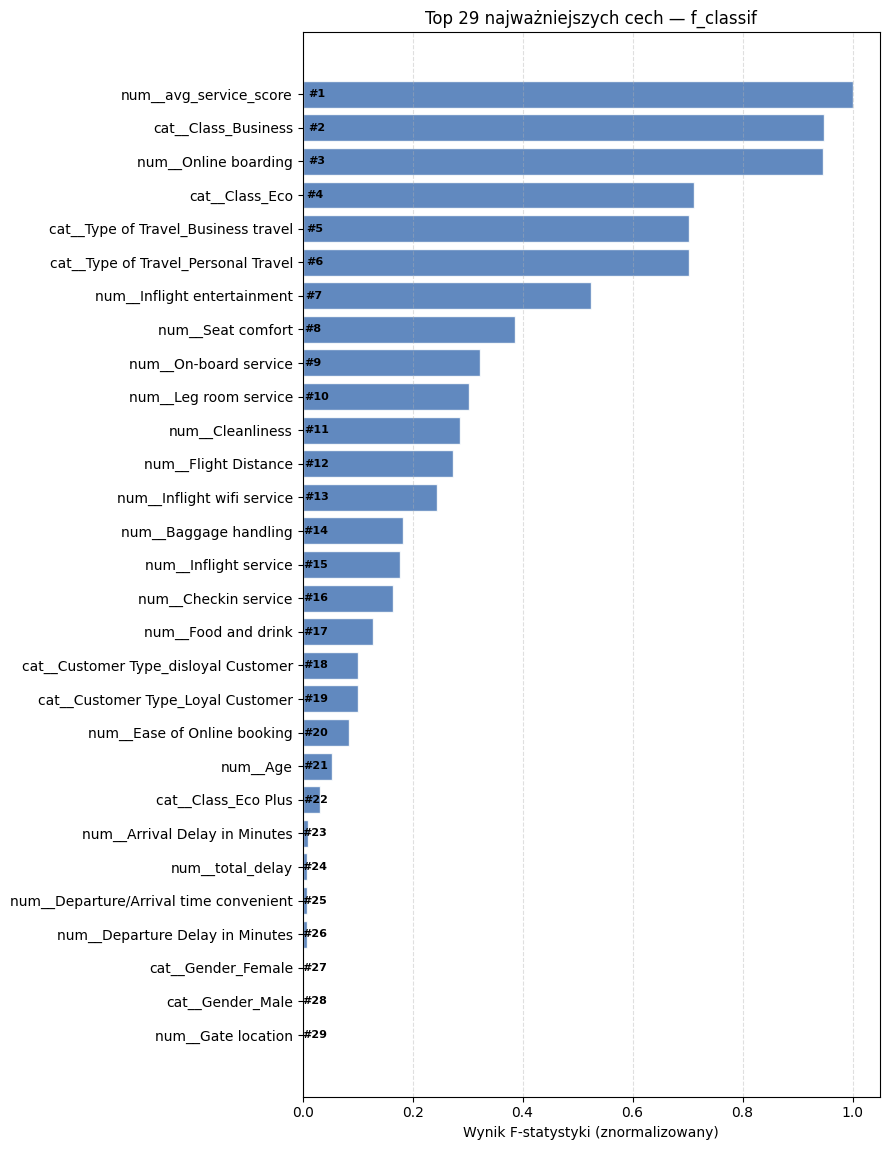

In [42]:
plot_feature_scores(scores_f,  top_n=29)

In [43]:
scores_mi = get_feature_scores(preprocessor, X_train, y_train, mutual_info_classif)
scores_mi

,feature,score_func,score,p_value,rank
0,num__Online boarding,mutual_info_classif,0.213153,NaN,1
1,num__Inflight wifi service,mutual_info_classif,0.164480,NaN,2
2,num__avg_service_score,mutual_info_classif,0.159357,NaN,3
3,cat__Class_Business,mutual_info_classif,0.139904,NaN,4
4,cat__Type of Travel_Business travel,mutual_info_classif,0.124869,NaN,5
5,cat__Type of Travel_Personal Travel,mutual_info_classif,0.117631,NaN,6
6,cat__Class_Eco,mutual_info_classif,0.116297,NaN,7
7,num__Inflight entertainment,mutual_info_classif,0.098153,NaN,8
8,num__Seat comfort,mutual_info_classif,0.079909,NaN,9
9,num__Leg room service,mutual_info_classif,0.064093,NaN,10


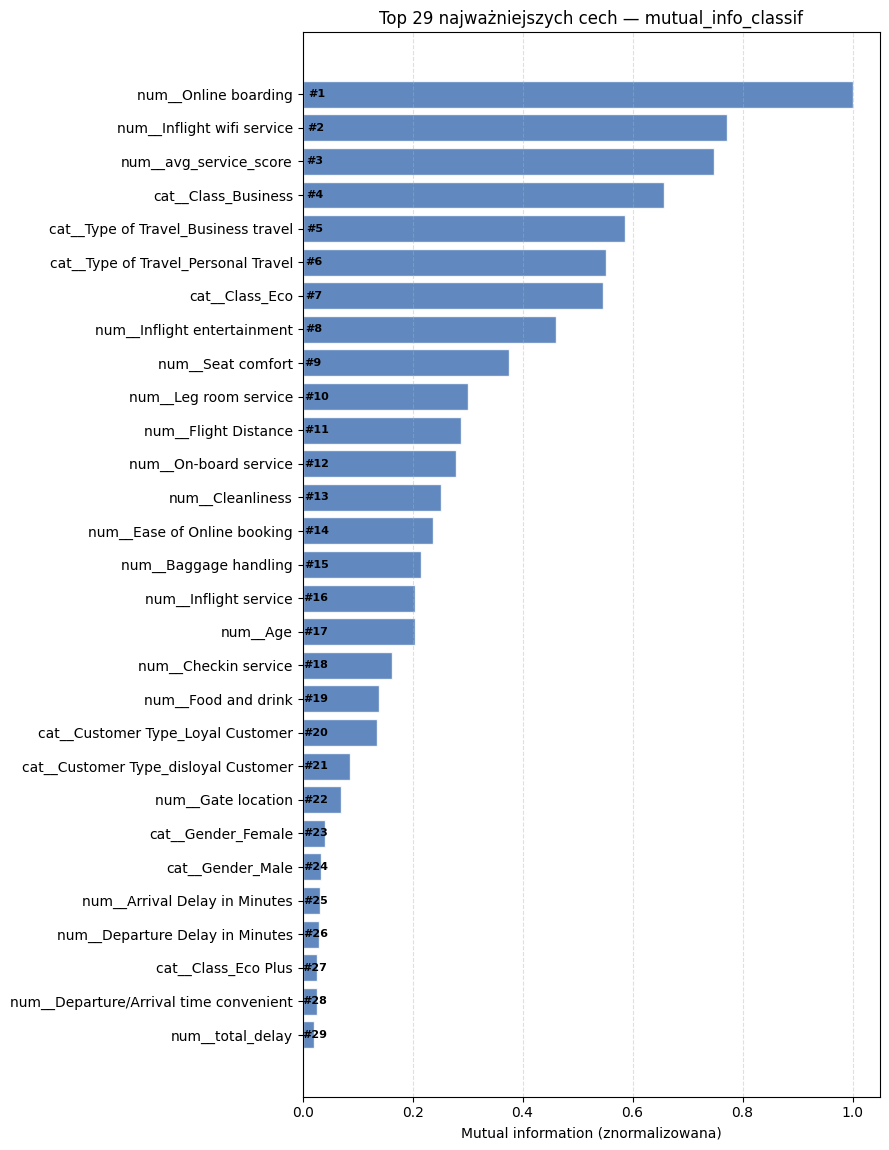

In [44]:
plot_feature_scores(scores_mi, top_n=29)

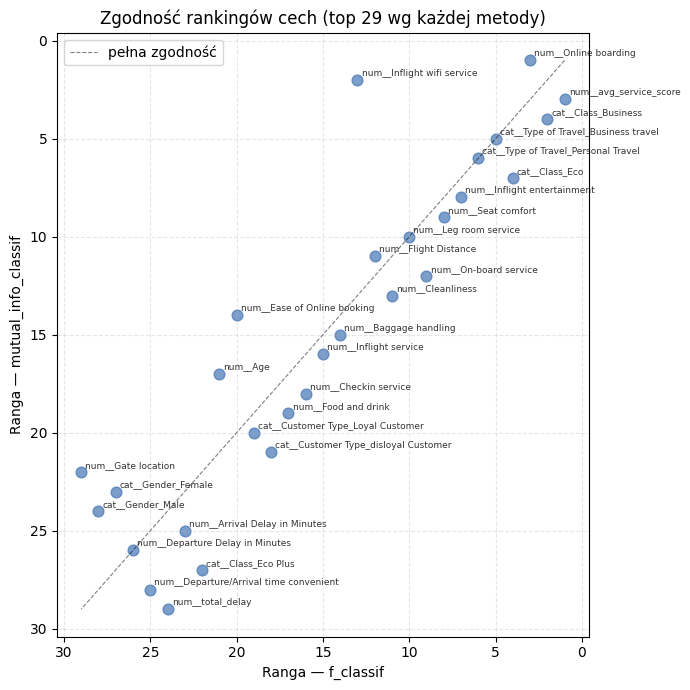

In [45]:
plot_rank_comparison(pd.concat([scores_f, scores_mi]), top_n=29)

### 5.2 Wnioski z SelectKBest

Zgodnie z postawioną hipotezą, usługi bezpośrednio wpływające na komfort pasażera są najsilniejszymi predyktorami. Obie metody jednoznacznie wskazują w ścisłej czołówce takie cechy jak: `avg_service_score` oraz `Online boarding`.

Mimo ogólnej spójności, warto zauważyć, że występują wyraźne różnice w istotności poszczególnych cech pomiędzy zastosowanymi podejściami. Najlepszym tego przykładem jest `Inflight wifi service`, który dla `mutual_info_classif` okazał się kluczowy i zajął drugie miejsce, podczas gdy dla `f_classif` spadł dopiero na trzynastą pozycję. Ponadto metody różnią się samym liderem rankingu.

Obie metody wykazują niemal pełną jednomyślność przy identyfikacji "ogona" zestawienia. Wynika z nich, że opóźnienia lotów (zarówno odlotu, jak i przylotu), płeć pasażera oraz lokalizacja bramki mają marginalny wpływ na końcowe zadowolenie z podróży i mogą być pominięte w procesie modelowania.

Wykresy liniowe obrazujące metryki (Accuracy, F1, ROC AUC) pokazują stromy wzrost jakości predykcji do poziomu 20 wyselekcjonowanych cech. Maksymalne wyniki model osiąga przy około 25 cechach, po czym krzywe się wypłaszczają. Potwierdza to przypuszczenie, że model można bezpiecznie uprościć (odrzucając kilka najsłabszych cech) bez utraty skuteczności, jednak zbyt agresywna selekcja (np. ograniczenie się do 10–15 cech) skutkuje już wyraźnym spadkiem jakości predykcji. Wybór konkretnej metody selekcji (`f_classif` vs `mutual_info_classif`) ma w tym przypadku znikomy wpływ na ostateczne wyniki modelu.

### 5.3 RFE (Recursive Feature Elimination)

Metoda iteracyjnie eliminuje najmniej istotne cechy na podstawie wag modelu. Porównano dwa estymatory bazowe: Regresję Logistyczną i Las Losowy.

In [46]:
custom_estimators = {
    "LR": LogisticRegression(C=0.01, l1_ratio=1.0, solver="saga", max_iter=5000, random_state=42),
    "RF": SklearnRF(n_estimators=100, random_state=42, n_jobs=1),
}

results_rfe = run_rfe_experiment(
    preprocessor, X_train, y_train, X_test, y_test,
    estimators=custom_estimators,
)

estimator=LR n_features=5 accuracy=0.8463 f1=0.8219 roc_auc=0.9063
estimator=LR n_features=10 accuracy=0.8663 f1=0.8451 roc_auc=0.9208
estimator=LR n_features=15 accuracy=0.8696 f1=0.8485 roc_auc=0.9240
estimator=LR n_features=20 accuracy=0.8721 f1=0.8512 roc_auc=0.9254
estimator=LR n_features=25 accuracy=0.8720 f1=0.8510 roc_auc=0.9255
estimator=LR n_features=all accuracy=0.8713 f1=0.8502 roc_auc=0.9255
estimator=RF n_features=5 accuracy=0.8216 f1=0.7920 roc_auc=0.8857
estimator=RF n_features=10 accuracy=0.8530 f1=0.8305 roc_auc=0.9104
estimator=RF n_features=15 accuracy=0.8639 f1=0.8421 roc_auc=0.9188
estimator=RF n_features=20 accuracy=0.8704 f1=0.8492 roc_auc=0.9240
estimator=RF n_features=25 accuracy=0.8714 f1=0.8504 roc_auc=0.9254
estimator=RF n_features=all accuracy=0.8713 f1=0.8502 roc_auc=0.9255


In [47]:
print(results_rfe.to_string(index=False))

estimator n_features  accuracy       f1  roc_auc
       LR          5  0.846329 0.821881 0.906295
       LR         10  0.866335 0.845069 0.920816
       LR         15  0.869579 0.848477 0.924013
       LR         20  0.872050 0.851161 0.925437
       LR         25  0.871973 0.851045 0.925478
       LR        all  0.871278 0.850209 0.925451
       RF          5  0.821612 0.791984 0.885715
       RF         10  0.853049 0.830474 0.910354
       RF         15  0.863940 0.842068 0.918812
       RF         20  0.870351 0.849239 0.923971
       RF         25  0.871432 0.850429 0.925435
       RF        all  0.871278 0.850209 0.925451


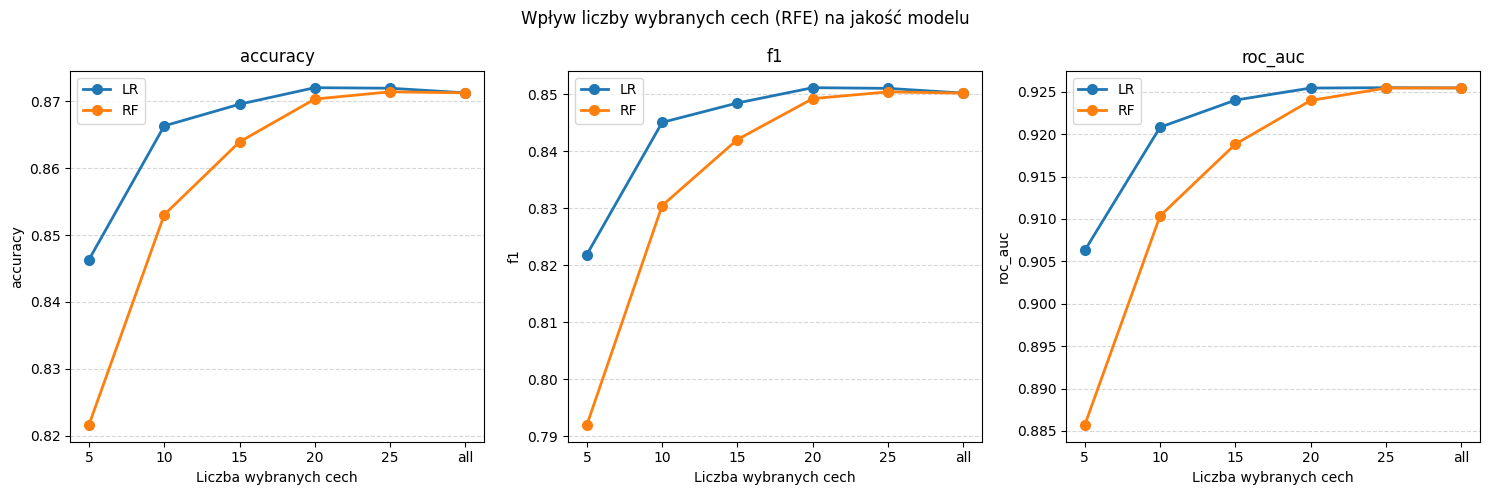

In [48]:
plot_n_features_vs_metrics(results_rfe)

In [49]:
rankings_lr = get_feature_rankings(preprocessor, X_train, y_train, estimator_name="LR", estimators=custom_estimators)
rankings_lr

,feature,ranking
0,cat__Type of Travel_Business travel,1
1,cat__Customer Type_disloyal Customer,2
2,cat__Type of Travel_Personal Travel,3
3,num__avg_service_score,4
4,cat__Class_Business,5
5,cat__Customer Type_Loyal Customer,6
6,num__Online boarding,7
7,num__Departure/Arrival time convenient,8
8,num__Ease of Online booking,9
9,num__Inflight wifi service,10


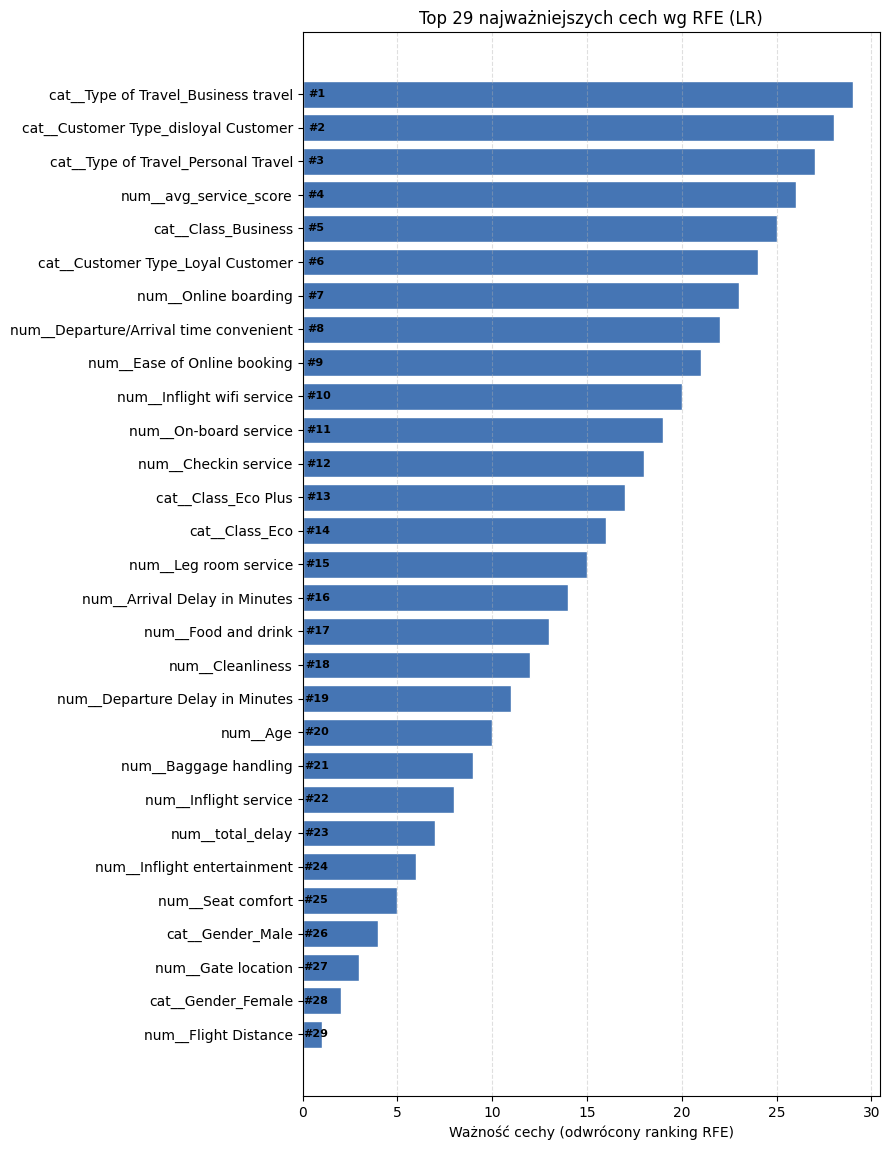

In [50]:
plot_feature_rankings(rankings_lr, estimator_name="LR", top_n=29)

In [51]:
rankings_rf = get_feature_rankings(preprocessor, X_train, y_train, estimator_name="RF", estimators=custom_estimators)
rankings_rf

,feature,ranking
0,num__Online boarding,1
1,num__Flight Distance,2
2,num__Inflight wifi service,3
3,cat__Class_Business,4
4,num__avg_service_score,5
5,cat__Type of Travel_Business travel,6
6,num__Age,7
7,num__Inflight entertainment,8
8,num__Ease of Online booking,9
9,cat__Type of Travel_Personal Travel,10


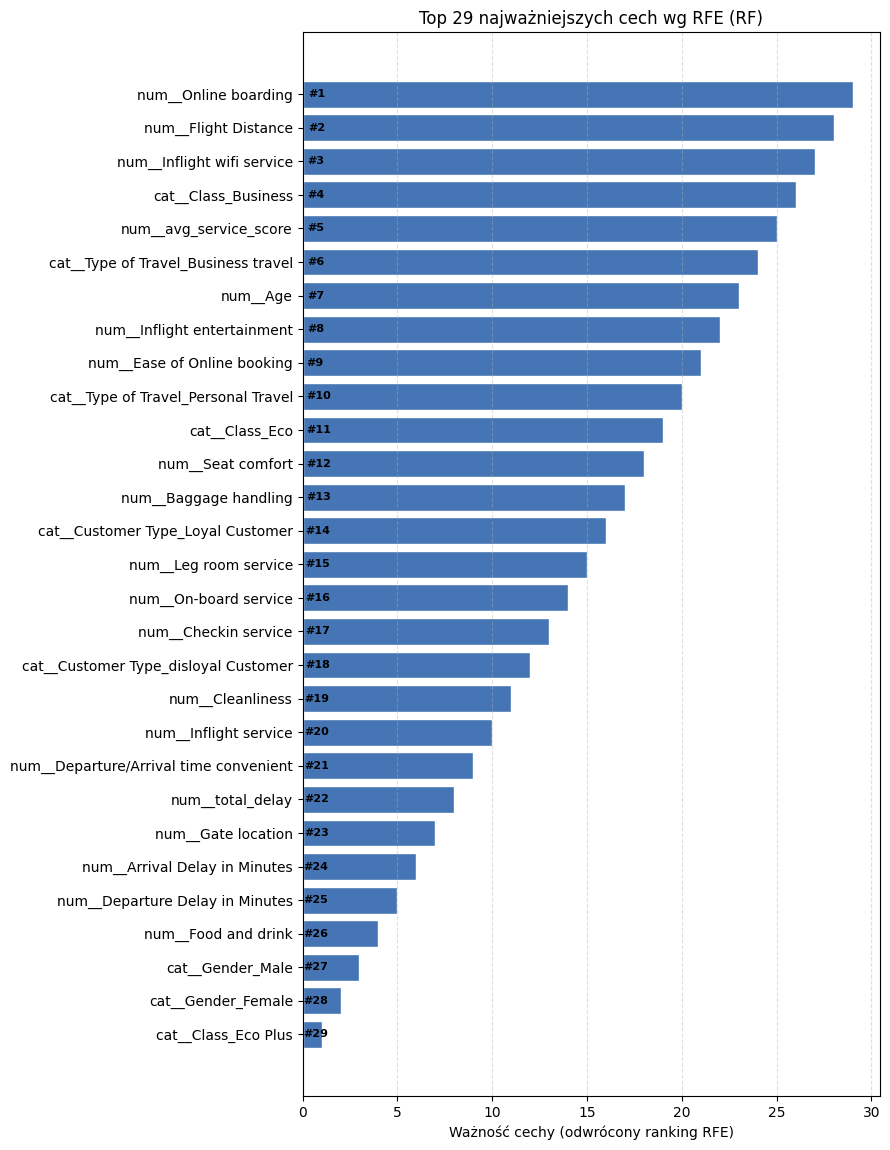

In [52]:
plot_feature_rankings(rankings_rf, estimator_name="RF", top_n=29)

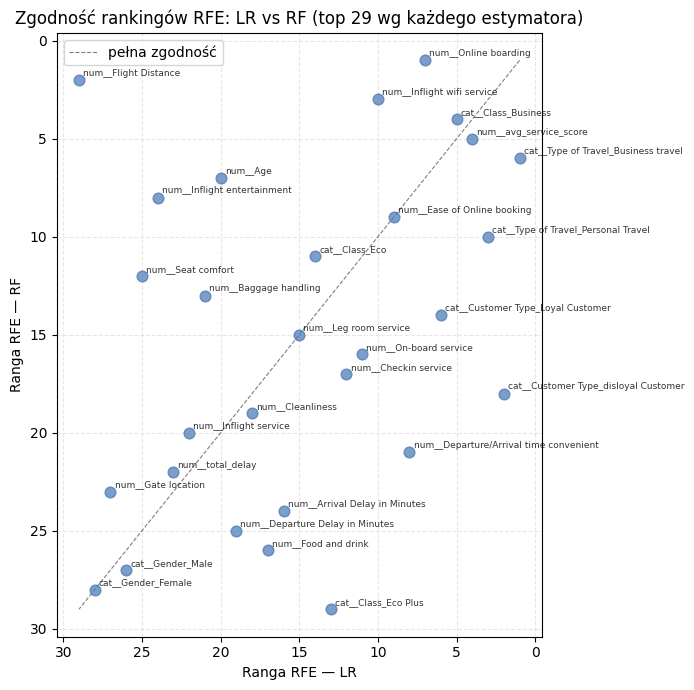

In [54]:
plot_feature_rankings_comparison(rankings_lr, rankings_rf, top_n=29)

### 5.4 Wnioski z RFE

Rankingi istotności uzyskane metodą RFE dla regresji logistycznej (LR) i lasu losowego (RF) wykazują wyraźne różnice. RFE dla regresji logistycznej nie wskazuje na `avg_service_score` jako na absolutnie kluczową cechę (plasuje ją na #4 miejscu), skupiając się w pierwszej kolejności na cechach kategorycznych związanych z profilem podróży i klienta. Z kolei RFE dla lasu losowego umieszcza `avg_service_score` (#5 miejsce), a na samego lidera wysuwa `Online boarding` oraz inne cechy związane z jakością lotu, takie jak `Flight distance` oraz `Inflight wifi service`.

Najbardziej jaskrawym dowodem na odmienną specyfikę obu modeli w procesie RFE jest cecha `Flight distance`. Dla lasu losowego jest to kluczowa zmienna (pozycja #2), podczas gdy dla regresji logistycznej stanowi ona całkowicie nieprzydatny szum informacyjny, przez co wylądowała na ostatnim (#29) miejscu.

Selekcja ~20–25 cech za pomocą RFE pozwala zachować pełną jakość bazowego modelu regresji logistycznej, co potwierdza założenia Eksperymentu 3.

Na wykresach metryk widać, że regresja logistyczna radzi sobie znacznie lepiej przy skrajnym ograniczeniu liczby cech (od 5 do 15) niż las losowy. RF przy zaledwie 5 cechach notuje drastyczny spadek efektywności (F1 spada w okolice 0.79), podczas gdy LR zachowuje stabilność (F1 ~0.82). Wynika to z faktu, że RFE dla LR bardzo precyzyjnie odfiltrowuje najsilniejsze predyktory stricte liniowe.

### 5.5 Podsumowanie Eksperymentu 3

Wszystkie przeprowadzone analizy zgodnie potwierdziły, że oceny komponentów obsługi pasażera dominują nad metrykami czysto technicznymi.

RFE dla lasu losowego wykazuje znacznie większą zgodność z wynikami SelectKBest (a w szczególności z metodą `mutual_info_classif`) niż RFE dla regresji logistycznej. Wynika to z naturalnej, zbieżnej zdolności lasu losowego i miary informacji wzajemnej do wychwytywania nieliniowych zależności oraz zaawansowanych interakcji między cechami.

Wszystkie podejścia okazały się zgodne przy wskazywaniu cech o zerowym lub marginalnym wpływie na satysfakcję. `total_delay`, `Arrival/Departure Delay`, `Gender` oraz `Gate location` niezmiennie okupują dolne paski każdego z rankingów i mogą zostać całkowicie usunięte.

Porównanie krzywych uczenia dla SelectKBest i RFE pozwala na wyciągnięcie jednoznacznego wniosku wdrożeniowego: redukcja zbioru danych do 20–25 najważniejszych cech gwarantuje zachowanie maksimum zdolności predykcyjnych modeli. Pozwala to na uproszczenie architektury systemów produkcyjnych, skrócenie czasu trenowania oraz łatwiejszą interpretację wyników bez jakiejkolwiek straty na jakości klasyfikacji.

## 6. Wnioski końcowe

| Aspekt | Wniosek |
|---|---|
| **Najlepszy model (pełne dane)** | XGBoost i Las Losowy — zbliżone wyniki (F1 ≈ 0.96, ROC AUC ≈ 0.995); XGBoost nieznacznie lepszy |
| **Hipoteza Eksperymentu 1** | ✓ Potwierdzona — XGBoost najlepszy na pełnych danych |
| **Hipoteza Eksperymentu 2** | ✓ Potwierdzona — TabPFN lepszy przy małych próbkach (100–500) |
| **Hipoteza Eksperymentu 3** | ✓ Potwierdzona — usługi pokładowe dominują; k ≈ 20 wystarczy dla regresji logistycznej |
| **Najważniejsze cechy** | `avg_service_score`, `Online boarding`, klasa podróży (`Business`/`Eco`) |
| **Zgodność SelectKBest i RFE** | Wysoka — obie metody wskazują ten sam zestaw kluczowych predyktorów |

**Rekomendacja praktyczna:**
- Do produkcji z pełnymi danymi: **XGBoost** lub **Las Losowy** (najwyższa jakość)
- Do zastosowań z deficytem danych treningowych: **TabPFN** (wyższa efektywność próbkowania)
- Do szybkiego, interpretowalnego modelu z selekcją cech: **Regresja logistyczna + SelectKBest (k=20)**

In [53]:
results_exp1.round(4).style.highlight_max(axis=0, props="font-weight: bold; color: green")

,Accuracy,F1,ROC AUC
Model,,,
Regresja logistyczna,0.871700,0.850700,0.925500
Las losowy,0.962500,0.956700,0.994000
XGBoost,0.964000,0.958500,0.995400
